# online_retail_II  
![Lionheart Emporium](image/UK-based_online_retailer.png)



<br>

---
## ACT: Define problem, business task, objective, questions and stakeholders invovled  
- **Stakeholders**: Marketing Manager, Head of Sales, Inventory/Operations Manger and Financial Controller.  
- **Problem**: The retailer has trouble with inventory management/optimization, due to a lack of visibility on seasonal sales trends, popular products, customer distribution and the broader international market performance.  
- **Business task**: Examine historical transaction data from a UK based online retailer to identify key growth drivers and customer purchasing habbits.     
- **Objectives**: Provide actionbable insights that will enable the retailer to increase reveune and effectively manage inventory.  
- **Questions**: What is the monthly revenue trend, Which products are the most popular and profitable,  Which countries contribute the most to sales, How does not having stock (poor inventory) affect net income?  
---
## Prepare: List data source, structure, ROCCC evaulation, tranformations, constraints and integrity  
- **Data source**:This dataset was made available by Dr. Daqing Chen, Course Director: MSc Data Science. chend '@' lsbu.ac.uk, School of Engineering, London South Bank University, London SE1 0AA, UK, and was downloaded from Kaggle [click this link](https://www.kaggle.com/datasets/tunguz/online-retail-ii).  
- **ROCCC Checklist**: Does this dataset **ROCCC** or not?  
  - **Reliable**: This dataset has a low to medium reliabitiy. For this dataset to be reliable I need to extenisively clean it and document the cleansing to make results reproducibly.  
  - **Original**: This dataset was made publicly available as by a secondary data source since it was not made available by the UK retailer (It is not original since it was not accessed from the UK retailer's internal database).   
  - **Comprehensive**: This dataset is very comprehensive for a retail analysis. It contains over 500,000 observations of transactions spanning a full year (Dec 2010 – Dec 2011).  
  - **Current**: The data is not current and is considered stale since it is from 2010 to 2011 which is more than 10 years back.  
  - **Cited**: This is one of the most famous datasets in data science. It is well-documented and cited in many academic papers including the official citation on the UCI Machine Learning Repository.  
- **Transformations**: This dataset was downloaded as a .zip file which contains the .csv file that will be imported  in the process phase.  
- **Data structure**: The dataset has 541,910 rows and 8 columns.   
  - **Columns**: Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country  
  - **Data Types**: String, String, String, Integer, String, Decimal, Decimal, String  
- **Constraints**: 25% of rows have null values for the Customer ID column, the dataset has *(135,080) null values in Customer ID column* this has a negative impact on customer-specific analysis like we can not count the exact number of customers. *Price and Quantity contain negative values* indicating adjustments or returns. We do not know the retailer's top line, therefore we must *create a column to calculate Total_Sales*. Some columns must be converted to their appropriate datatypes, columns to *convert InvoiceDate to Date-Time and Customer ID to Integer or String*.  
- **Data Integrity**: This data does not include Personal Identifiable Information like Phone numbers, Identity numbers or credit card numbers, so users privacy is protected.    
- **Tool selection**: Python, I chose python because it can easily handle large dataset, has a rich ecosystem of data science liabraries and reproducible data cleaning pipeline.  
---
## Process: Clean the data / Handle contraints  
### Set up the environment: Load liabraries and dataset  

  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings as w

In [2]:
online_retail_2 = pd.read_csv(r"C:\Users\itumeleng\Desktop\Python Programs\case_studies\datasets\online_retail_II.csv", encoding="latin-1") 
online_retail_2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Rename columns: Remove spaces and uppercase letters

In [3]:
online_retail_2.columns = [col.lower().replace(' ','_') for col in online_retail_2.columns]
online_retail_2 = online_retail_2.rename(columns={
  'stockcode' : 'stock_code',
  'invoicedate' : 'invoice_date'
})

### View the datatypes of each column

In [4]:
online_retail_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice       541910 non-null  object 
 1   stock_code    541910 non-null  object 
 2   description   540456 non-null  object 
 3   quantity      541910 non-null  int64  
 4   invoice_date  541910 non-null  object 
 5   price         541910 non-null  float64
 6   customer_id   406830 non-null  float64
 7   country       541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Convert InvoiceDate Data type to Date-time

In [5]:
online_retail_2['invoice_date'] = pd.to_datetime(online_retail_2['invoice_date'], format='%m/%d/%y  %H:%M')

### View Number of rows

In [6]:
row_count_1 = online_retail_2.shape[0]
print('The dataset contains:', row_count_1, ' rows')

The dataset contains: 541910  rows


### Handle Customer ID: Remove nulls and convert Data type to integer

In [7]:
online_retail_2 = online_retail_2.dropna(subset=['customer_id'])
online_retail_2['customer_id'] = online_retail_2['customer_id'].astype(str)

### View Number of rows

In [8]:
row_count_2 = online_retail_2.shape[0]
print('The dataset now contains:', row_count_2, ' rows,', row_count_1 - row_count_2, 'null rows from the customer_id column were removed.')

The dataset now contains: 406830  rows, 135080 null rows from the customer_id column were removed.


### View the data types to verify columns have been converted

In [9]:
online_retail_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406830 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       406830 non-null  object        
 1   stock_code    406830 non-null  object        
 2   description   406830 non-null  object        
 3   quantity      406830 non-null  int64         
 4   invoice_date  406830 non-null  datetime64[ns]
 5   price         406830 non-null  float64       
 6   customer_id   406830 non-null  object        
 7   country       406830 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


### Handle Negative values from the price and qualtity: Remove cancellations and adjustments from sales 

In [10]:
online_retail_2 = online_retail_2[(online_retail_2['quantity'] > 0) & (online_retail_2['price'] > 0)].copy()
row_count_3 = online_retail_2.shape[0]
print('The dataset now contains:',row_count_3,'rows,', row_count_2 - row_count_3, 'rows containing cancellations were removed')

The dataset now contains: 397885 rows, 8945 rows containing cancellations were removed


### Create a total_sales column: Calculate revenue per line item

In [11]:
online_retail_2['total_sales'] = online_retail_2['quantity'] * online_retail_2['price']
online_retail_2.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Create a month_year column: Extract moth and year from invoice_date for trend analysis

In [12]:
online_retail_2['month_year'] = online_retail_2['invoice_date'].dt.to_period('M').astype(str)
online_retail_2.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,total_sales,month_year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


### Save the clean dataframe as a .csv file

In [13]:
online_retail_2.to_csv(r"C:\Users\itumeleng\Desktop\Python Programs\case_studies\datasets\processed\cleaned_online_retail.csv",index = False)

  
---
## Analyse: Perform calculations and aggregate data 
### Create a table to calculate revenue for each month

In [14]:
monthly_revenue = online_retail_2.groupby('month_year')['total_sales'].sum().reset_index()
monthly_revenue

,month_year,total_sales
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


### Create a table to view top 10 products by revenue

In [15]:
top_products_by_revenue = online_retail_2.groupby('description')['total_sales'].sum().sort_values(ascending = False).head(10).reset_index()
top_products_by_revenue

,description,total_sales
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77821.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


### Geographic performance: Top 10 international countries by revenue

In [16]:
international_sales = online_retail_2[online_retail_2['country'] != 'United Kingdom'] 
top_international_countries = international_sales.groupby('country')['total_sales'].sum().sort_values(ascending = False).head(10).reset_index()
top_international_countries

,country,total_sales
0,Netherlands,285446.34
1,EIRE,265545.90
2,Germany,228867.14
3,France,209042.05
4,Australia,138521.31
5,Spain,61577.11
6,Switzerland,56443.95
7,Belgium,41196.34
8,Sweden,38378.33
9,Japan,37416.37


### Calculate the top line: total revenue generated

In [17]:
total_revenue = online_retail_2['total_sales'].sum()
print(f"The total net reveune is: ${total_revenue:,.2f}")

The total net reveune is: $8,911,425.90


### Calculate the average revenue per order

In [18]:
avg_order_revenue = online_retail_2.groupby('invoice')['total_sales'].sum().mean()
print(f"The average order value is: ${avg_order_revenue:,.2f}")

The average order value is: $480.87


### Calculate the average monthly revenue

In [19]:
avg_monthly_revenue = monthly_revenue['total_sales'].mean()
print(f"The average monthly revenue is: ${avg_monthly_revenue:,.2f}")

The average monthly revenue is: $685,494.30



---
## Share: Create visuals to communicate data insights   
### Set a theme for visuals

In [20]:
sns.set_theme(style = 'whitegrid')

### Create a line plot to visualize monthly sales

In [21]:

w.filterwarnings('ignore', category=FutureWarning) #### Code to ignore future warnings for cleaner output

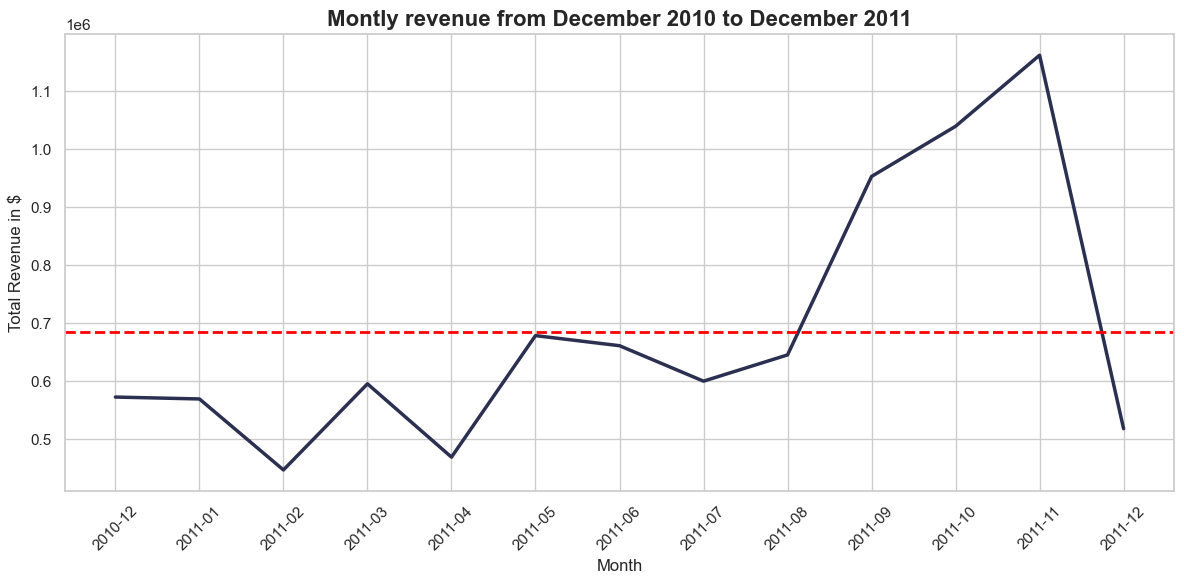

In [22]:
plt.figure(figsize=(12,6))
sns.lineplot(data = monthly_revenue, x = 'month_year', y = 'total_sales', markers = 'o', linewidth = 2.5, color = "#2c3050")
plt.axhline(avg_monthly_revenue, color='red', linestyle='--', linewidth=2, label=f'Average (${avg_monthly_revenue:,.0f})')
plt.title('Montly revenue from December 2010 to December 2011', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Total Revenue in $', fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Create a bar chart to visualize popular products

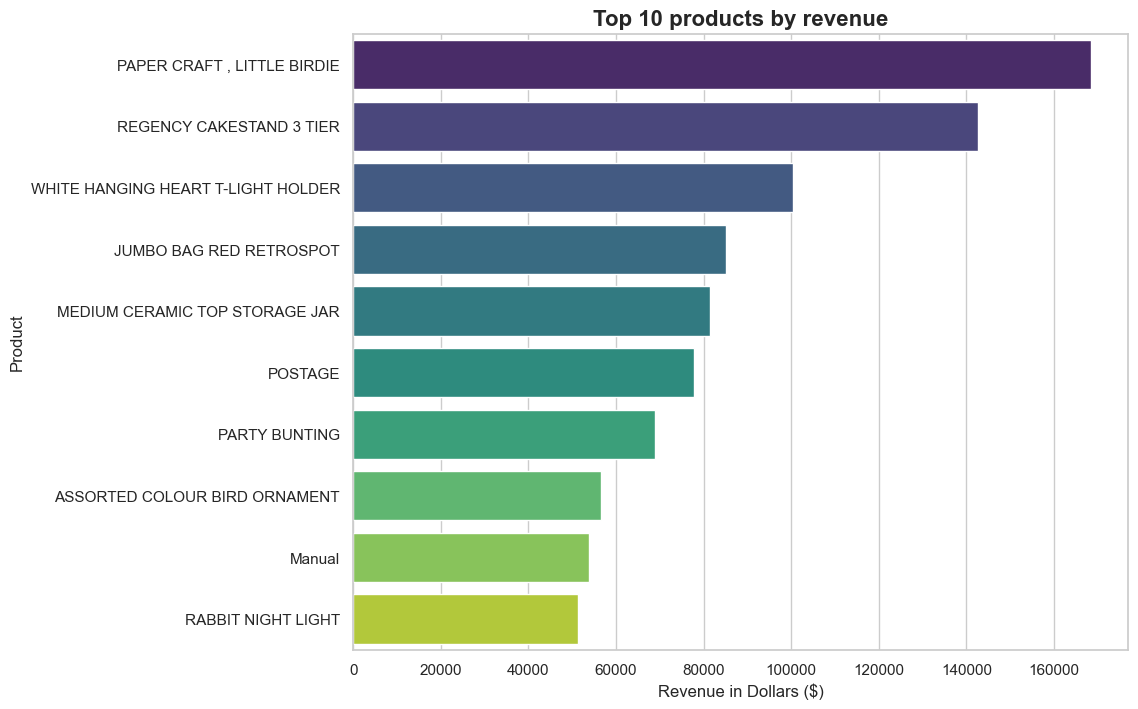

In [23]:
plt.figure(figsize=(10,8))
sns.barplot(data = top_products_by_revenue, x = 'total_sales', y = 'description', palette = 'viridis')
plt.title('Top 10 products by revenue', fontsize = 16, fontweight = 'bold')
plt.xlabel('Revenue in Dollars ($)', fontsize = 12)
plt.ylabel('Product', fontsize = 12)
plt.show()

### Create a bar chart to view top 10 international countries

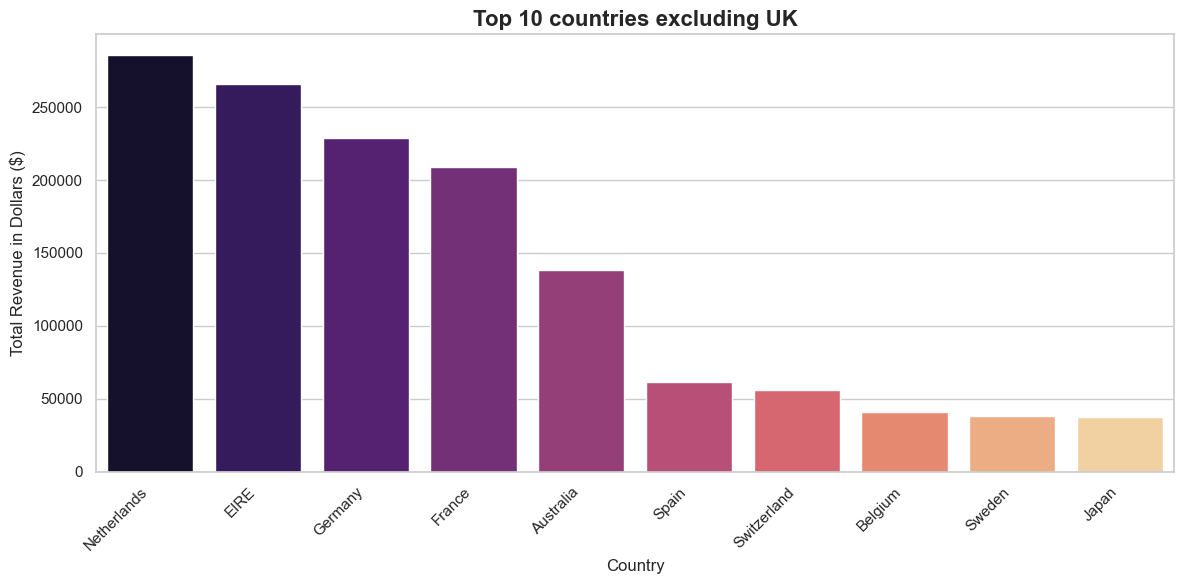

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(data = top_international_countries, x = 'country', y = 'total_sales', palette = 'magma')
plt.title('Top 10 countries excluding UK', fontsize = 16, fontweight = 'bold')
plt.xlabel('Country', fontsize = 12)
plt.ylabel('Total Revenue in Dollars ($)', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()


---
## Act: Provide actionable recommendations  
Based on  the analysis, here are three actionable recommendations for the UK-based online retailer  
1. **Optimize Inventory for Quarter 4**: Revenue nearly doubles between August and November, so the business should increase stock levels for popular products starting in late August to avoid stockouts during the holiday peak.  
2. **Targeted International Marketing**: The Netherlands and EIRE show significant reveune potential. The business should create marketing campaigns to target or localize shipping promotions in these regions to improve international market share.  
3. **Implement a Customer Retention Program**: The data shows a high volume of transactions, creating a loyalty program based on Recency, Frequency, Monetary (RFM) data. To help identify and reward high-value customers, ensuring they purchase even during offf-peak months (February to April) to boost sales during the sales dip.  